## Important Limitation

This notebook creates **28 separate approximate postal-district regions (D01-D28)** from the 55 URA Master Plan 2019 planning areas. So some areas have to be dropped/merged to fit rental dataset.

## Setup

In [75]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from pathlib import Path
from shapely import make_valid

In [76]:
raw_geojson_path = Path(
    "..",
    "Datasets",
    "MasterPlan2019PlanningAreaBoundaryNoSea.geojson"
)

processed_folder_path = Path(
    "..",
    "Cleaned Datasets"
)

processed_geojson_path = (
    processed_folder_path
    / "Postal_Districts_Cleaned.geojson"
)

rental_file_path = (
    processed_folder_path
    / "commercial_retail_rental_clean.csv"
)

print("Raw GeoJSON:")
print(raw_geojson_path)

print("\nProcessed GeoJSON:")
print(processed_geojson_path)

Raw GeoJSON:
..\Datasets\MasterPlan2019PlanningAreaBoundaryNoSea.geojson

Processed GeoJSON:
..\Cleaned Datasets\Postal_Districts_Cleaned.geojson


In [77]:
if raw_geojson_path.exists():
    print("Planning-area GeoJSON found.")
else:
    print("Planning-area GeoJSON not found.")

Planning-area GeoJSON found.


In [78]:
planning_area_raw = gpd.read_file(
    raw_geojson_path
)

planning_area_raw.head()

,OBJECTID,PLN_AREA_N,PLN_AREA_C,CA_IND,REGION_N,REGION_C,INC_CRC,FMEL_UPD_D,SHAPE.AREA,SHAPE.LEN,geometry
0,1,BEDOK,BD,N,EAST REGION,ER,5F00E6FF084F3364,20191223152014,2.173397e+07,21864.234336,"POLYGON ((103.93208 1.30555, 103.93208 1.30555..."
1,2,BOON LAY,BL,N,WEST REGION,WR,C96AED188C00B2FC,20191223152014,8.282808e+06,18542.688792,"POLYGON ((103.72042 1.32824, 103.72066 1.32865..."
2,3,BUKIT BATOK,BK,N,WEST REGION,WR,3BEC4C829160F28A,20191223152014,1.114018e+07,15236.442232,"POLYGON ((103.76408 1.37001, 103.76385 1.37036..."
3,4,BUKIT MERAH,BM,N,CENTRAL REGION,CR,4850795BB0B6A4F7,20191223152014,1.446120e+07,29161.409834,"POLYGON ((103.82361 1.26018, 103.82368 1.26018..."
4,5,BUKIT PANJANG,BP,N,WEST REGION,WR,656F87D23D6DAB02,20191223152014,9.019940e+06,15891.853279,"POLYGON ((103.77445 1.39029, 103.77444 1.39029..."


## Initial Checks and Data Exploration

In [79]:
print("Number of rows and columns:")
print(planning_area_raw.shape)

print("\nColumn names:")
print(planning_area_raw.columns.tolist())

print("\nCoordinate reference system:")
print(planning_area_raw.crs)

print("\nGeometry types:")
print(planning_area_raw.geometry.geom_type.value_counts())

Number of rows and columns:
(55, 11)

Column names:
['OBJECTID', 'PLN_AREA_N', 'PLN_AREA_C', 'CA_IND', 'REGION_N', 'REGION_C', 'INC_CRC', 'FMEL_UPD_D', 'SHAPE.AREA', 'SHAPE.LEN', 'geometry']

Coordinate reference system:
EPSG:4326

Geometry types:
Polygon         46
MultiPolygon     9
Name: count, dtype: int64


In [80]:
print("Missing values:")
print(planning_area_raw.isnull().sum())

print("\nDuplicated planning-area names:")
print(
    planning_area_raw["PLN_AREA_N"]
    .duplicated()
    .sum()
)

print("\nInvalid geometries:")
print(
    (~planning_area_raw.geometry.is_valid)
    .sum()
)

Missing values:
OBJECTID      0
PLN_AREA_N    0
PLN_AREA_C    0
CA_IND        0
REGION_N      0
REGION_C      0
INC_CRC       0
FMEL_UPD_D    0
SHAPE.AREA    0
SHAPE.LEN     0
geometry      0
dtype: int64

Duplicated planning-area names:
0

Invalid geometries:
5


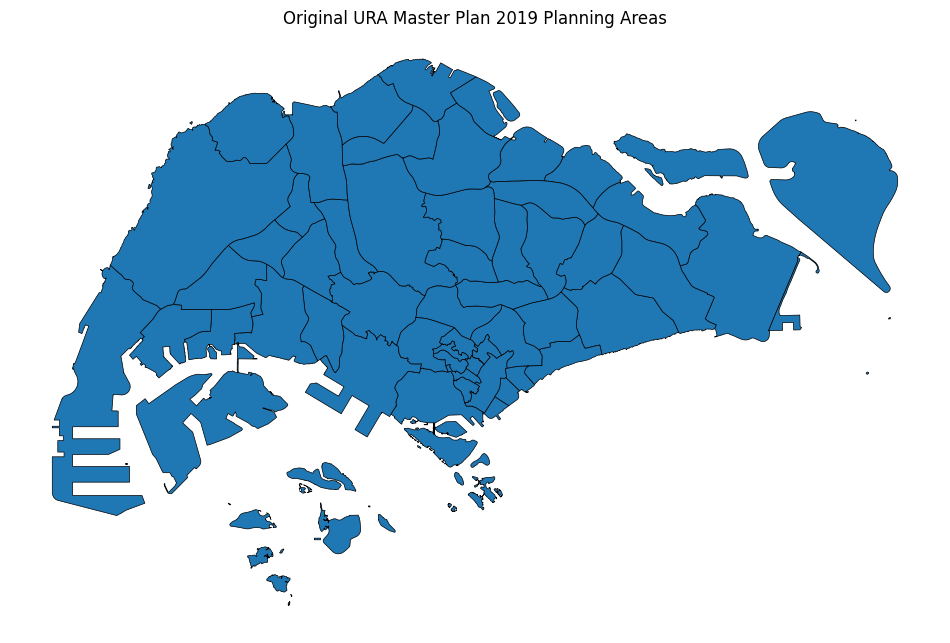

In [81]:
figure, axis = plt.subplots(
    figsize=(12, 9)
)

planning_area_raw.plot(
    ax=axis,
    edgecolor="black",
    linewidth=0.5
)

axis.set_title(
    "Original URA Master Plan 2019 Planning Areas"
)

axis.set_axis_off()

plt.show()

In [82]:
planning_area = planning_area_raw[[
    "OBJECTID",
    "PLN_AREA_N",
    "PLN_AREA_C",
    "REGION_N",
    "REGION_C",
    "geometry"
]].copy()

planning_area = planning_area.rename(columns={
    "OBJECTID": "object_id",
    "PLN_AREA_N": "planning_area",
    "PLN_AREA_C": "planning_area_code",
    "REGION_N": "region",
    "REGION_C": "region_code"
})

planning_area.head()

,object_id,planning_area,planning_area_code,region,region_code,geometry
0,1,BEDOK,BD,EAST REGION,ER,"POLYGON ((103.93208 1.30555, 103.93208 1.30555..."
1,2,BOON LAY,BL,WEST REGION,WR,"POLYGON ((103.72042 1.32824, 103.72066 1.32865..."
2,3,BUKIT BATOK,BK,WEST REGION,WR,"POLYGON ((103.76408 1.37001, 103.76385 1.37036..."
3,4,BUKIT MERAH,BM,CENTRAL REGION,CR,"POLYGON ((103.82361 1.26018, 103.82368 1.26018..."
4,5,BUKIT PANJANG,BP,WEST REGION,WR,"POLYGON ((103.77445 1.39029, 103.77444 1.39029..."


In [83]:
text_columns = [
    "planning_area",
    "planning_area_code",
    "region",
    "region_code"
]

for column in text_columns:
    planning_area[column] = (
        planning_area[column]
        .astype("string")
        .str.strip()
        .str.upper()
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
    )

In [84]:
if planning_area.crs is None:
    planning_area = planning_area.set_crs(
        "EPSG:4326"
    )
else:
    planning_area = planning_area.to_crs(
        "EPSG:4326"
    )

print("Cleaned coordinate reference system:")
print(planning_area.crs)

Cleaned coordinate reference system:
EPSG:4326


## Cleaning the Geometries

In [85]:
planning_area_before_repair = (
    planning_area.copy()
)

planning_area["geometry_was_repaired"] = (
    ~planning_area.geometry.is_valid
)

invalid_before_repair = planning_area[
    planning_area["geometry_was_repaired"]
][[
    "planning_area",
    "region"
]]

print("Invalid geometries before repair:")
print(len(invalid_before_repair))

display(invalid_before_repair)

Invalid geometries before repair:
5


,planning_area,region
0,BEDOK,EAST REGION
3,BUKIT MERAH,CENTRAL REGION
11,JURONG EAST,WEST REGION
23,NORTH-EASTERN ISLANDS,NORTH-EAST REGION
26,SOUTHERN ISLANDS,CENTRAL REGION


In [86]:
planning_area["geometry"] = (
    planning_area["geometry"]
    .apply(make_valid)
)

In [87]:
print("Invalid geometries after repair:")
print(
    (~planning_area.geometry.is_valid)
    .sum()
)

print("\nMissing geometries:")
print(
    planning_area.geometry.isnull()
    .sum()
)

print("\nEmpty geometries:")
print(
    planning_area.geometry.is_empty
    .sum()
)

print("\nGeometry types after repair:")
print(
    planning_area.geometry.geom_type
    .value_counts()
)

Invalid geometries after repair:
0

Missing geometries:
0

Empty geometries:
0

Geometry types after repair:
Polygon         46
MultiPolygon     9
Name: count, dtype: int64


In [88]:
area_before_repair = (
    planning_area_before_repair
    .to_crs("EPSG:3414")
    .geometry
    .area
    .sum()
)

area_after_repair = (
    planning_area
    .to_crs("EPSG:3414")
    .geometry
    .area
    .sum()
)

repair_area_difference = (
    area_after_repair
    - area_before_repair
)

repair_area_difference_percentage = (
    abs(repair_area_difference)
    / area_before_repair
    * 100
)

print("Percentage area difference after repair:")
print(repair_area_difference_percentage)

Percentage area difference after repair:
1.5187432686768447e-14


## Assigning Planning Areas to D01-D28

In [89]:
district_names = {
    "D01": "Raffles Place, Cecil, Marina, People's Park",
    "D02": "Anson, Tanjong Pagar",
    "D03": "Queenstown, Tiong Bahru",
    "D04": "Telok Blangah, Harbourfront",
    "D05": "Pasir Panjang, Hong Leong Garden, Clementi New Town",
    "D06": "High Street, Beach Road (part)",
    "D07": "Middle Road, Golden Mile",
    "D08": "Little India",
    "D09": "Orchard, Cairnhill, River Valley",
    "D10": "Ardmore, Bukit Timah, Holland Road, Tanglin",
    "D11": "Watten Estate, Novena, Thomson",
    "D12": "Balestier, Toa Payoh, Serangoon",
    "D13": "Macpherson, Braddell",
    "D14": "Geylang, Eunos",
    "D15": "Katong, Joo Chiat, Amber Road",
    "D16": "Bedok, Upper East Coast, Eastwood, Kew Drive",
    "D17": "Loyang, Changi",
    "D18": "Tampines, Pasir Ris",
    "D19": "Serangoon Garden, Hougang, Punggol",
    "D20": "Bishan, Ang Mo Kio",
    "D21": "Upper Bukit Timah, Clementi Park, Ulu Pandan",
    "D22": "Jurong",
    "D23": "Hillview, Dairy Farm, Bukit Panjang, Choa Chu Kang",
    "D24": "Lim Chu Kang, Tengah",
    "D25": "Kranji, Woodgrove",
    "D26": "Upper Thomson, Springleaf",
    "D27": "Yishun, Sembawang",
    "D28": "Seletar"
}

In [90]:
planning_area_to_district = {
    # Central districts
    "DOWNTOWN CORE": "D01",
    "MARINA EAST": "D01",
    "MARINA SOUTH": "D01",
    "STRAITS VIEW": "D01",
    "SINGAPORE RIVER": "D01",
    "OUTRAM": "D02",
    "QUEENSTOWN": "D03",
    "BUKIT MERAH": "D04",
    "SOUTHERN ISLANDS": "D04",
    "CLEMENTI": "D05",
    "MUSEUM": "D06",
    "ROCHOR": "D07",
    "KALLANG": "D08",
    "ORCHARD": "D09",
    "RIVER VALLEY": "D09",
    "TANGLIN": "D10",
    "NEWTON": "D11",
    "NOVENA": "D11",
    "TOA PAYOH": "D12",
    "PAYA LEBAR": "D13",
    "GEYLANG": "D14",
    "MARINE PARADE": "D15",

    # East and north-east districts
    "BEDOK": "D16",
    "CHANGI": "D17",
    "CHANGI BAY": "D17",
    "TAMPINES": "D18",
    "PASIR RIS": "D18",
    "SERANGOON": "D19",
    "HOUGANG": "D19",
    "SENGKANG": "D19",
    "PUNGGOL": "D19",
    "NORTH-EASTERN ISLANDS": "D19",
    "BISHAN": "D20",
    "ANG MO KIO": "D20",

    # West and north districts
    "BUKIT TIMAH": "D21",
    "JURONG EAST": "D22",
    "JURONG WEST": "D22",
    "BOON LAY": "D22",
    "PIONEER": "D22",
    "TUAS": "D22",
    "WESTERN ISLANDS": "D22",
    "BUKIT BATOK": "D23",
    "BUKIT PANJANG": "D23",
    "CHOA CHU KANG": "D23",
    "LIM CHU KANG": "D24",
    "TENGAH": "D24",
    "WESTERN WATER CATCHMENT": "D24",
    "WOODLANDS": "D25",
    "SUNGEI KADUT": "D25",
    "MANDAI": "D26",
    "CENTRAL WATER CATCHMENT": "D26",
    "YISHUN": "D27",
    "SEMBAWANG": "D27",
    "SIMPANG": "D27",
    "SELETAR": "D28"
}

In [91]:
geojson_planning_areas = set(
    planning_area["planning_area"]
)

mapped_planning_areas = set(
    planning_area_to_district.keys()
)

missing_from_mapping = sorted(
    geojson_planning_areas
    - mapped_planning_areas
)

not_found_in_geojson = sorted(
    mapped_planning_areas
    - geojson_planning_areas
)

print("GeoJSON planning areas missing from mapping:")
print(missing_from_mapping)

print("\nMapping names not found in GeoJSON:")
print(not_found_in_geojson)

print("\nNumber of mapped planning areas:")
print(len(planning_area_to_district))

GeoJSON planning areas missing from mapping:
[]

Mapping names not found in GeoJSON:
[]

Number of mapped planning areas:
55


In [92]:
if missing_from_mapping or not_found_in_geojson:
    raise ValueError(
        "The planning-area mapping does not match the GeoJSON."
    )

print("All planning-area names match correctly.")

All planning-area names match correctly.


In [93]:
planning_area["postal_district"] = (
    planning_area["planning_area"]
    .map(planning_area_to_district)
)

planning_area["postal_district_name"] = (
    planning_area["postal_district"]
    .map(district_names)
)

planning_area["postal_district_number"] = (
    planning_area["postal_district"]
    .str.replace(
        "D",
        "",
        regex=False
    )
    .astype(int)
)

planning_area["postal_district_label"] = (
    planning_area["postal_district"]
    + " / "
    + planning_area["postal_district_name"]
)

planning_area["mapping_method"] = (
    "Whole planning area assigned to dominant or closest postal district"
)

In [94]:
planning_area_mapping_check = planning_area[[
    "planning_area",
    "region",
    "postal_district",
    "postal_district_name"
]].sort_values([
    "postal_district",
    "planning_area"
])

display(planning_area_mapping_check)

,planning_area,region,postal_district,postal_district_name
39,DOWNTOWN CORE,CENTRAL REGION,D01,"Raffles Place, Cecil, Marina, People's Park"
40,MARINA EAST,CENTRAL REGION,D01,"Raffles Place, Cecil, Marina, People's Park"
41,MARINA SOUTH,CENTRAL REGION,D01,"Raffles Place, Cecil, Marina, People's Park"
35,SINGAPORE RIVER,CENTRAL REGION,D01,"Raffles Place, Cecil, Marina, People's Park"
36,STRAITS VIEW,CENTRAL REGION,D01,"Raffles Place, Cecil, Marina, People's Park"
45,OUTRAM,CENTRAL REGION,D02,"Anson, Tanjong Pagar"
16,QUEENSTOWN,CENTRAL REGION,D03,"Queenstown, Tiong Bahru"
3,BUKIT MERAH,CENTRAL REGION,D04,"Telok Blangah, Harbourfront"
26,SOUTHERN ISLANDS,CENTRAL REGION,D04,"Telok Blangah, Harbourfront"
9,CLEMENTI,WEST REGION,D05,"Pasir Panjang, Hong Leong Garden, Clementi New..."


In [95]:
print("Unmapped planning areas:")
print(
    planning_area["postal_district"]
    .isnull()
    .sum()
)

print("\nNumber of represented postal districts:")
print(
    planning_area["postal_district"]
    .nunique()
)

print("\nPlanning areas assigned more than once:")
print(
    planning_area["planning_area"]
    .duplicated()
    .sum()
)

Unmapped planning areas:
0

Number of represented postal districts:
28

Planning areas assigned more than once:
0


## Creating the Final D01-D28 GeoJSON

In [96]:
district_geometry = (
    planning_area[[
        "postal_district",
        "geometry"
    ]]
    .dissolve(
        by="postal_district",
        as_index=False
    )
)

district_geometry.head()

,postal_district,geometry
0,D01,"POLYGON ((103.86626 1.27271, 103.8661 1.27259,..."
1,D02,"POLYGON ((103.84313 1.28778, 103.84259 1.28782..."
2,D03,"POLYGON ((103.7846 1.31109, 103.78432 1.31121,..."
3,D04,"MULTIPOLYGON (((103.82912 1.24079, 103.82914 1..."
4,D05,"POLYGON ((103.76707 1.3312, 103.76706 1.33123,..."


In [97]:
district_summary = (
    planning_area
    .groupby(
        "postal_district",
        as_index=False
    )
    .agg(
        planning_area_count=(
            "planning_area",
            "count"
        ),
        planning_areas=(
            "planning_area",
            lambda values:
                " | ".join(sorted(values))
        ),
        source_regions=(
            "region",
            lambda values:
                " | ".join(
                    sorted(set(values))
                )
        )
    )
)

district_summary.head()

,postal_district,planning_area_count,planning_areas,source_regions
0,D01,5,DOWNTOWN CORE | MARINA EAST | MARINA SOUTH | S...,CENTRAL REGION
1,D02,1,OUTRAM,CENTRAL REGION
2,D03,1,QUEENSTOWN,CENTRAL REGION
3,D04,2,BUKIT MERAH | SOUTHERN ISLANDS,CENTRAL REGION
4,D05,1,CLEMENTI,WEST REGION


In [98]:
district_information = pd.DataFrame({
    "postal_district": list(
        district_names.keys()
    ),
    "postal_district_name": list(
        district_names.values()
    )
})

district_information[
    "postal_district_number"
] = (
    district_information[
        "postal_district"
    ]
    .str.replace(
        "D",
        "",
        regex=False
    )
    .astype(int)
)

district_information[
    "postal_district_label"
] = (
    district_information[
        "postal_district"
    ]
    + " / "
    + district_information[
        "postal_district_name"
    ]
)

district_information.head()

,postal_district,postal_district_name,postal_district_number,postal_district_label
0,D01,"Raffles Place, Cecil, Marina, People's Park",1,"D01 / Raffles Place, Cecil, Marina, People's Park"
1,D02,"Anson, Tanjong Pagar",2,"D02 / Anson, Tanjong Pagar"
2,D03,"Queenstown, Tiong Bahru",3,"D03 / Queenstown, Tiong Bahru"
3,D04,"Telok Blangah, Harbourfront",4,"D04 / Telok Blangah, Harbourfront"
4,D05,"Pasir Panjang, Hong Leong Garden, Clementi New...",5,"D05 / Pasir Panjang, Hong Leong Garden, Clemen..."


In [99]:
postal_district_map = district_geometry.merge(
    district_summary,
    on="postal_district",
    how="left",
    validate="one_to_one"
)

postal_district_map = postal_district_map.merge(
    district_information,
    on="postal_district",
    how="left",
    validate="one_to_one"
)

postal_district_map["mapping_method"] = (
    "Approximate boundary created from whole URA planning areas"
)

postal_district_map = postal_district_map[[
    "postal_district_number",
    "postal_district",
    "postal_district_name",
    "postal_district_label",
    "planning_area_count",
    "planning_areas",
    "source_regions",
    "mapping_method",
    "geometry"
]]

postal_district_map = (
    postal_district_map
    .sort_values(
        "postal_district_number"
    )
    .reset_index(drop=True)
)

postal_district_map = gpd.GeoDataFrame(
    postal_district_map,
    geometry="geometry",
    crs="EPSG:4326"
)

postal_district_map.head()

,postal_district_number,postal_district,postal_district_name,postal_district_label,planning_area_count,planning_areas,source_regions,mapping_method,geometry
0,1,D01,"Raffles Place, Cecil, Marina, People's Park","D01 / Raffles Place, Cecil, Marina, People's Park",5,DOWNTOWN CORE | MARINA EAST | MARINA SOUTH | S...,CENTRAL REGION,Approximate boundary created from whole URA pl...,"POLYGON ((103.86626 1.27271, 103.8661 1.27259,..."
1,2,D02,"Anson, Tanjong Pagar","D02 / Anson, Tanjong Pagar",1,OUTRAM,CENTRAL REGION,Approximate boundary created from whole URA pl...,"POLYGON ((103.84313 1.28778, 103.84259 1.28782..."
2,3,D03,"Queenstown, Tiong Bahru","D03 / Queenstown, Tiong Bahru",1,QUEENSTOWN,CENTRAL REGION,Approximate boundary created from whole URA pl...,"POLYGON ((103.7846 1.31109, 103.78432 1.31121,..."
3,4,D04,"Telok Blangah, Harbourfront","D04 / Telok Blangah, Harbourfront",2,BUKIT MERAH | SOUTHERN ISLANDS,CENTRAL REGION,Approximate boundary created from whole URA pl...,"MULTIPOLYGON (((103.82912 1.24079, 103.82914 1..."
4,5,D05,"Pasir Panjang, Hong Leong Garden, Clementi New...","D05 / Pasir Panjang, Hong Leong Garden, Clemen...",1,CLEMENTI,WEST REGION,Approximate boundary created from whole URA pl...,"POLYGON ((103.76707 1.3312, 103.76706 1.33123,..."


In [100]:
postal_district_map["geometry"] = (
    postal_district_map["geometry"]
    .apply(make_valid)
)

print("Number of final postal-district regions:")
print(len(postal_district_map))

print("\nInvalid final geometries:")
print(
    (~postal_district_map.geometry.is_valid)
    .sum()
)

Number of final postal-district regions:
28

Invalid final geometries:
0


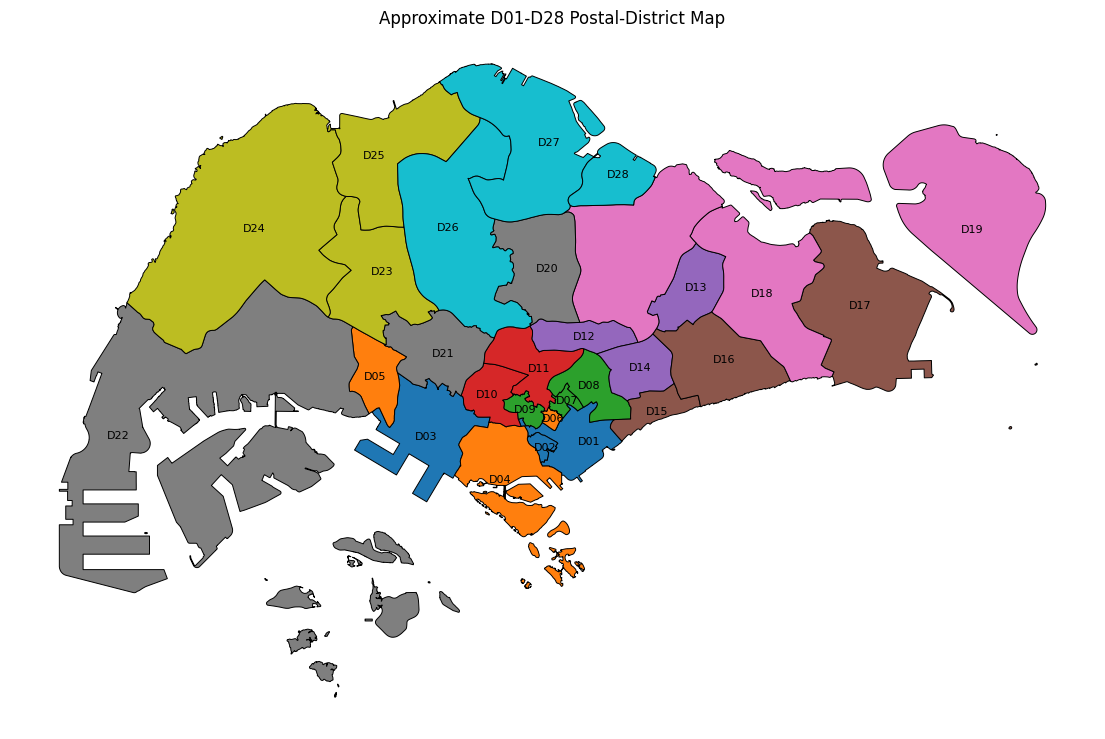

In [101]:
postal_district_map_projected = (
    postal_district_map
    .to_crs("EPSG:3414")
)

figure, axis = plt.subplots(
    figsize=(14, 10)
)

postal_district_map_projected.plot(
    ax=axis,
    column="postal_district_number",
    categorical=True,
    edgecolor="black",
    linewidth=0.7,
    legend=False
)

for row_number, row in (
    postal_district_map_projected
    .iterrows()
):
    label_point = (
        row.geometry
        .representative_point()
    )

    axis.text(
        label_point.x,
        label_point.y,
        row["postal_district"],
        horizontalalignment="center",
        verticalalignment="center",
        fontsize=8
    )

axis.set_title(
    "Approximate D01-D28 Postal-District Map"
)

axis.set_axis_off()

plt.show()

## Final Validation Checks

In [102]:
expected_postal_districts = {
    f"D{number:02d}"
    for number in range(1, 29)
}

actual_postal_districts = set(
    postal_district_map[
        "postal_district"
    ]
)

missing_postal_districts = sorted(
    expected_postal_districts
    - actual_postal_districts
)

unexpected_postal_districts = sorted(
    actual_postal_districts
    - expected_postal_districts
)

print("Missing postal districts:")
print(missing_postal_districts)

print("\nUnexpected postal districts:")
print(unexpected_postal_districts)

print("\nNumber of postal districts:")
print(len(postal_district_map))

Missing postal districts:
[]

Unexpected postal districts:
[]

Number of postal districts:
28


In [103]:
print("Missing values:")
print(
    postal_district_map[[
        "postal_district",
        "postal_district_name",
        "geometry"
    ]]
    .isnull()
    .sum()
)

print("\nDuplicated postal-district codes:")
print(
    postal_district_map[
        "postal_district"
    ]
    .duplicated()
    .sum()
)

print("\nInvalid geometries:")
print(
    (~postal_district_map.geometry.is_valid)
    .sum()
)

print("\nEmpty geometries:")
print(
    postal_district_map.geometry.is_empty
    .sum()
)

Missing values:
postal_district         0
postal_district_name    0
geometry                0
dtype: int64

Duplicated postal-district codes:
0

Invalid geometries:
0

Empty geometries:
0


In [104]:
planning_area_total_area = (
    planning_area
    .to_crs("EPSG:3414")
    .geometry
    .area
    .sum()
)

postal_district_total_area = (
    postal_district_map
    .to_crs("EPSG:3414")
    .geometry
    .area
    .sum()
)

dissolve_area_difference = (
    postal_district_total_area
    - planning_area_total_area
)

dissolve_area_difference_percentage = (
    abs(dissolve_area_difference)
    / planning_area_total_area
    * 100
)

print("Planning-area total area:")
print(planning_area_total_area)

print("\nPostal-district total area:")
print(postal_district_total_area)

print("\nPercentage area difference:")
print(dissolve_area_difference_percentage)

Planning-area total area:
784920611.7281326

Postal-district total area:
784920609.591771

Percentage area difference:
2.72175499922846e-07


In [105]:
district_projected = (
    postal_district_map
    .to_crs("EPSG:3414")
)

overlap_records = []

for first_index, first_row in (
    district_projected.iterrows()
):
    for second_index, second_row in (
        district_projected.iterrows()
    ):
        if first_index < second_index:
            overlap_area = (
                first_row.geometry
                .intersection(
                    second_row.geometry
                )
                .area
            )

            if overlap_area > 1:
                overlap_records.append({
                    "first_district":
                        first_row[
                            "postal_district"
                        ],
                    "second_district":
                        second_row[
                            "postal_district"
                        ],
                    "overlap_area_sqm":
                        overlap_area
                })

overlap_check = pd.DataFrame(
    overlap_records
)

print("District pairs overlapping by more than 1 square metre:")
print(len(overlap_check))

display(overlap_check)

District pairs overlapping by more than 1 square metre:
0


""


In [106]:
if rental_file_path.exists():
    rental_check = pd.read_csv(
        rental_file_path
    )

    rental_districts = set(
        rental_check[
            "postal_district"
        ]
        .dropna()
        .unique()
    )

    map_districts = set(
        postal_district_map[
            "postal_district"
        ]
    )

    rental_without_geometry = sorted(
        rental_districts
        - map_districts
    )

    geometry_without_rental = sorted(
        map_districts
        - rental_districts
    )

    print("Rental districts without geometry:")
    print(rental_without_geometry)

    print("\nGeometry districts without rental data:")
    print(geometry_without_rental)
else:
    print(
        "Cleaned rental CSV not found. "
        "Rental-to-map validation was skipped."
    )

Cleaned rental CSV not found. Rental-to-map validation was skipped.


In [107]:
if (
    missing_postal_districts
    or unexpected_postal_districts
    or len(postal_district_map) != 28
    or postal_district_map[
        "postal_district"
    ].duplicated().any()
    or (
        ~postal_district_map.geometry.is_valid
    ).any()
    or postal_district_map.geometry.is_empty.any()
    or len(overlap_check) > 0
):
    raise ValueError(
        "One or more final validation checks failed."
    )

print("All final validation checks passed.")

All final validation checks passed.


## Saving the Final GeoJSON

In [108]:
processed_folder_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed Data folder is ready.")

Processed Data folder is ready.


In [109]:
postal_district_map = (
    postal_district_map
    .to_crs("EPSG:4326")
)

postal_district_map.to_file(
    processed_geojson_path,
    driver="GeoJSON",
    index=False
)

print("Final postal-district GeoJSON saved successfully.")
print(processed_geojson_path)

Final postal-district GeoJSON saved successfully.
..\Cleaned Datasets\Postal_Districts_Cleaned.geojson


In [110]:
if processed_geojson_path.exists():
    print("Saved GeoJSON found.")
else:
    print("Saved GeoJSON was not created.")

Saved GeoJSON found.


## Final Cleaned Dataset

In [111]:
postal_district_saved_check = (
    gpd.read_file(
        processed_geojson_path
    )
)

print("Saved GeoJSON shape:")
print(
    postal_district_saved_check.shape
)

print("\nSaved postal districts:")
print(
    postal_district_saved_check[
        "postal_district"
    ]
    .sort_values()
    .tolist()
)

print("\nSaved invalid geometries:")
print(
    (
        ~postal_district_saved_check
        .geometry
        .is_valid
    )
    .sum()
)

display(
    postal_district_saved_check
    .drop(columns="geometry")
    .head()
)

Saved GeoJSON shape:
(28, 9)

Saved postal districts:
['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19', 'D20', 'D21', 'D22', 'D23', 'D24', 'D25', 'D26', 'D27', 'D28']

Saved invalid geometries:
0


,postal_district_number,postal_district,postal_district_name,postal_district_label,planning_area_count,planning_areas,source_regions,mapping_method
0,1,D01,"Raffles Place, Cecil, Marina, People's Park","D01 / Raffles Place, Cecil, Marina, People's Park",5,DOWNTOWN CORE | MARINA EAST | MARINA SOUTH | S...,CENTRAL REGION,Approximate boundary created from whole URA pl...
1,2,D02,"Anson, Tanjong Pagar","D02 / Anson, Tanjong Pagar",1,OUTRAM,CENTRAL REGION,Approximate boundary created from whole URA pl...
2,3,D03,"Queenstown, Tiong Bahru","D03 / Queenstown, Tiong Bahru",1,QUEENSTOWN,CENTRAL REGION,Approximate boundary created from whole URA pl...
3,4,D04,"Telok Blangah, Harbourfront","D04 / Telok Blangah, Harbourfront",2,BUKIT MERAH | SOUTHERN ISLANDS,CENTRAL REGION,Approximate boundary created from whole URA pl...
4,5,D05,"Pasir Panjang, Hong Leong Garden, Clementi New...","D05 / Pasir Panjang, Hong Leong Garden, Clemen...",1,CLEMENTI,WEST REGION,Approximate boundary created from whole URA pl...
